# Who Is Hiring: 15 Years of Hacker News Job Postings

Every month since April 2011, Hacker News has hosted an "Ask HN: Who is hiring?"
thread where companies post openings. This notebook analyzes 93,122 postings
across 183 monthly threads, April 2011 to September 2026.

Data collection and parsing are in `src/`. This notebook only reads the
processed postings table.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

PROJECT_ROOT = Path("..")
POSTINGS_PATH = PROJECT_ROOT / "data" / "processed" / "postings.parquet"
FIGURES_DIRECTORY = PROJECT_ROOT / "figures"
FIGURES_DIRECTORY.mkdir(exist_ok=True)

# Reset any style injected by the editor theme, then pin our own.
# Every figure gets a white background so saved PNGs look the same
# on GitHub regardless of a viewer's light or dark mode.
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

# Shared palette so every chart in the notebook matches.
MONTHLY_COLOR = "#a9bcd0"
TREND_COLOR = "#1f4e79"
ANNOTATION_COLOR = "#444444"
SUBTITLE_COLOR = "#666666"
POSITIVE_COLOR = "#4a8c5c"
NEGATIVE_COLOR = "#b5483f"

In [13]:
postings = pd.read_parquet(POSTINGS_PATH)

postings["month_start"] = pd.to_datetime(
    postings["year"].astype(str) + "-" + postings["month"].astype(str) + "-01"
)

# December 2011's thread has 4 comments against ~290 in neighboring months.
# It was broken or superseded, not a quiet month, so it is treated as missing.
BROKEN_THREAD_MONTH = pd.Timestamp("2011-12-01")
postings = postings[postings["month_start"] != BROKEN_THREAD_MONTH]

print(f"Postings: {len(postings):,}")
print(f"Range: {postings['month_start'].min():%B %Y} to "
      f"{postings['month_start'].max():%B %Y}")

Postings: 93,121
Range: April 2011 to September 2026


## 1. Posting volume

How many companies posted each month.
Missing months (July 2011, April and May 2015, and the broken December 2011
thread) are left as gaps rather than interpolated.

In [14]:
monthly_counts = postings.groupby("month_start").size()

full_month_range = pd.date_range(
    monthly_counts.index.min(),
    monthly_counts.index.max(),
    freq="MS",
)
monthly_counts = monthly_counts.reindex(full_month_range)

missing_months = monthly_counts[monthly_counts.isna()].index
print("Months with no usable thread:",
      [month.strftime("%Y-%m") for month in missing_months])

# min_periods lets the average run through a gap instead of breaking.
rolling_average = monthly_counts.rolling(window=12, min_periods=9).mean()

Months with no usable thread: ['2011-07', '2011-12', '2015-04', '2015-05']


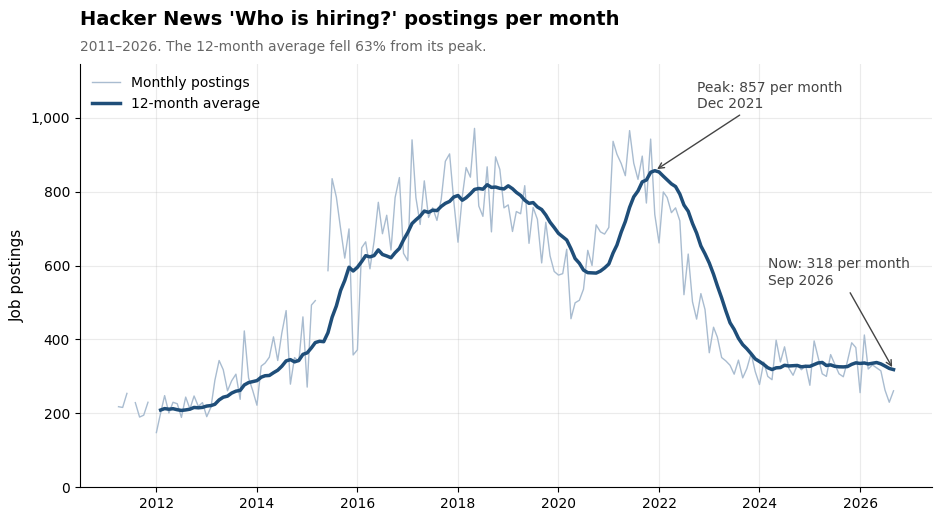

In [15]:
rolling_peak_month = rolling_average.idxmax()
rolling_peak_value = rolling_average.max()
latest_month = rolling_average.index.max()
latest_value = rolling_average.loc[latest_month]
decline_from_peak = 1 - (latest_value / rolling_peak_value)

figure, axis = plt.subplots()

axis.plot(
    monthly_counts.index,
    monthly_counts.values,
    color=MONTHLY_COLOR,
    linewidth=1,
    label="Monthly postings",
)
axis.plot(
    rolling_average.index,
    rolling_average.values,
    color=TREND_COLOR,
    linewidth=2.5,
    label="12-month average",
)

# Label positions are offsets from the points they describe, so they
# stay sensible if the data is refreshed with new months.
peak_label_position = (
    rolling_peak_month + pd.DateOffset(months=10),
    rolling_peak_value + 170,
)
axis.annotate(
    f"Peak: {rolling_peak_value:,.0f} per month\n{rolling_peak_month:%b %Y}",
    xy=(rolling_peak_month, rolling_peak_value),
    xytext=peak_label_position,
    color=ANNOTATION_COLOR,
    arrowprops={"arrowstyle": "->", "color": ANNOTATION_COLOR},
)

latest_label_position = (
    latest_month - pd.DateOffset(months=30),
    latest_value + 230,
)
axis.annotate(
    f"Now: {latest_value:,.0f} per month\n{latest_month:%b %Y}",
    xy=(latest_month, latest_value),
    xytext=latest_label_position,
    color=ANNOTATION_COLOR,
    arrowprops={"arrowstyle": "->", "color": ANNOTATION_COLOR},
)

axis.set_title(
    "Hacker News 'Who is hiring?' postings per month",
    loc="left",
    pad=28,
)
axis.text(
    0,
    1.03,
    f"2011–2026. The 12-month average fell {decline_from_peak:.0%} from its peak.",
    transform=axis.transAxes,
    color=SUBTITLE_COLOR,
)

axis.set_ylabel("Job postings")
axis.set_ylim(0, monthly_counts.max() * 1.18)
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.legend(loc="upper left", frameon=False)

figure.savefig(FIGURES_DIRECTORY / "01_monthly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
annual_summary = postings.groupby("year").agg(
    postings=("comment_id", "count"),
    months_observed=("month_start", "nunique"),
)
annual_summary["postings_per_month"] = (
    annual_summary["postings"] / annual_summary["months_observed"]
)
annual_summary["change_vs_prior_year"] = annual_summary["postings_per_month"].pct_change()

print(annual_summary.round(3).to_string())

decline_from_peak = 1 - (latest_value / rolling_peak_value)
print(f"\n12-month average: {rolling_peak_value:,.0f}/month at peak "
      f"({rolling_peak_month:%b %Y}), {latest_value:,.0f}/month now "
      f"({latest_month:%b %Y}) — a {decline_from_peak:.0%} decline.")

      postings  months_observed  postings_per_month  change_vs_prior_year
year                                                                     
2011      1532                7             218.857                   NaN
2012      2594               12             216.167                -0.012
2013      3432               12             286.000                 0.323
2014      4315               12             359.583                 0.257
2015      5851               10             585.100                 0.627
2016      8030               12             669.167                 0.144
2017      9423               12             785.250                 0.173
2018      9686               12             807.167                 0.028
2019      8434               12             702.833                -0.129
2020      7120               12             593.333                -0.156
2021     10279               12             856.583                 0.444
2022      7578               12       

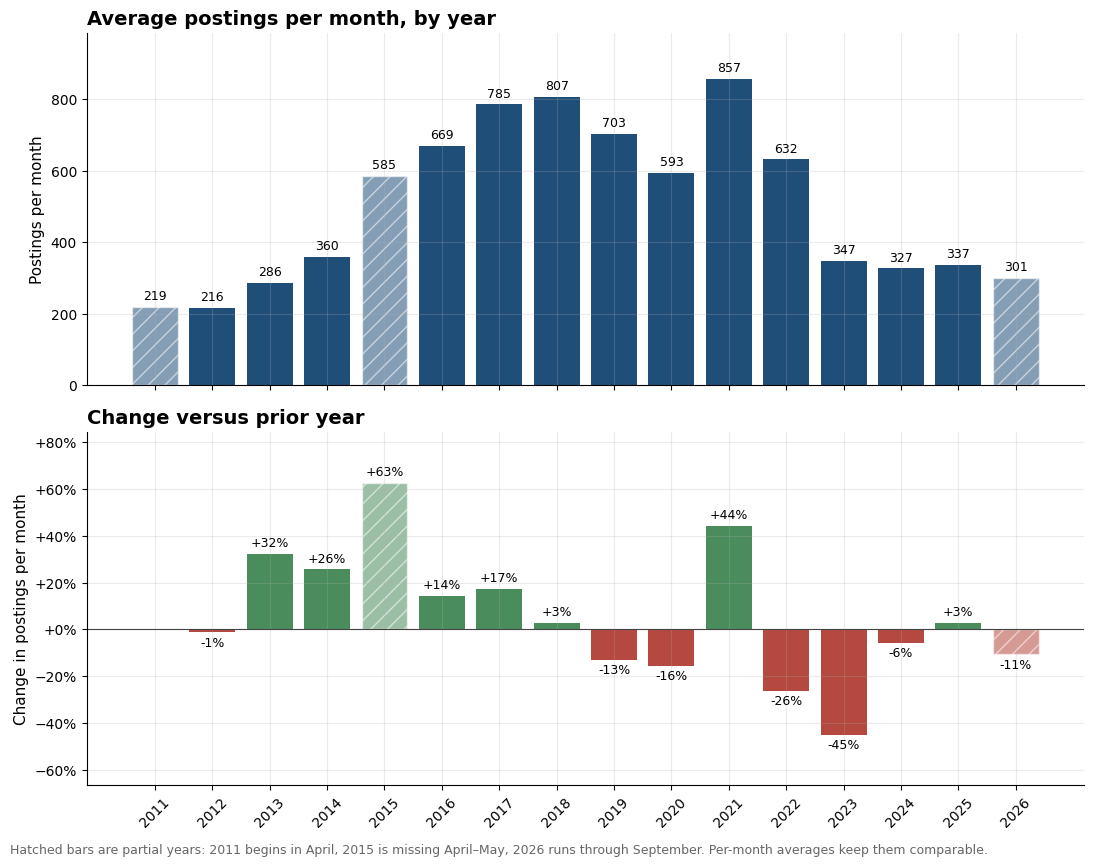

In [17]:
years = annual_summary.index.astype(int)
postings_per_month = annual_summary["postings_per_month"]
yearly_change_percent = annual_summary["change_vs_prior_year"] * 100
is_partial_year = annual_summary["months_observed"] < 12

figure, (volume_axis, change_axis) = plt.subplots(
    2,
    1,
    figsize=(11, 8.5),
    sharex=True,
)

# Top panel: average postings per month in each year.
volume_bars = volume_axis.bar(years, postings_per_month, color=TREND_COLOR)

for bar, partial in zip(volume_bars, is_partial_year):
    if partial:
        bar.set_alpha(0.55)
        bar.set_hatch("//")
        bar.set_edgecolor("white")

volume_labels = [f"{value:,.0f}" for value in postings_per_month]
volume_axis.bar_label(volume_bars, labels=volume_labels, padding=3, fontsize=9)

volume_axis.set_title("Average postings per month, by year", loc="left")
volume_axis.set_ylabel("Postings per month")
volume_axis.set_ylim(0, postings_per_month.max() * 1.15)
volume_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Bottom panel: change versus the prior year. 2011 has no prior year.
has_prior_year = yearly_change_percent.notna()
change_years = years[has_prior_year]
change_values = yearly_change_percent[has_prior_year]
change_is_partial = is_partial_year[has_prior_year]

change_colors = []
for value in change_values:
    if value >= 0:
        change_colors.append(POSITIVE_COLOR)
    else:
        change_colors.append(NEGATIVE_COLOR)

change_bars = change_axis.bar(change_years, change_values, color=change_colors)

for bar, partial in zip(change_bars, change_is_partial):
    if partial:
        bar.set_alpha(0.55)
        bar.set_hatch("//")
        bar.set_edgecolor("white")

change_labels = [f"{value:+.0f}%" for value in change_values]
change_axis.bar_label(change_bars, labels=change_labels, padding=3, fontsize=9)

change_axis.axhline(0, color=ANNOTATION_COLOR, linewidth=0.8)
change_axis.set_title("Change versus prior year", loc="left")
change_axis.set_ylabel("Change in postings per month")
change_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:+.0f}%"))
change_axis.margins(y=0.2)

change_axis.set_xticks(years)
change_axis.tick_params(axis="x", rotation=45)

figure.text(
    0.01,
    -0.01,
    "Hatched bars are partial years: 2011 begins in April, 2015 is missing April–May, "
    "2026 runs through September. Per-month averages keep them comparable.",
    color=SUBTITLE_COLOR,
    fontsize=9,
)

figure.tight_layout()
figure.savefig(FIGURES_DIRECTORY / "02_annual_volume.png", dpi=150, bbox_inches="tight")
plt.show()